In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib
import plotly.express as px

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

features_path = PROCESSED_DIR / "housing_dataset_europe_features.csv"
model_path = MODELS_DIR / "best_global_europe_model.joblib"

df = pd.read_csv(features_path)
df["date"] = pd.to_datetime(df["date"])

model_bundle = joblib.load(model_path)

pipeline = model_bundle["pipeline"]
feature_cols = model_bundle["feature_cols"]
best_model_name = model_bundle["best_model_name"]

best_model_name

'Lasso alpha=0.1'

In [2]:
ISO_MAPPING = {
    "Alemania": "DEU",
    "Austria": "AUT",
    "Bélgica": "BEL",
    "Bulgaria": "BGR",
    "Chequia": "CZE",
    "Chipre": "CYP",
    "Croacia": "HRV",
    "Dinamarca": "DNK",
    "Eslovaquia": "SVK",
    "Eslovenia": "SVN",
    "España": "ESP",
    "Estonia": "EST",
    "Finlandia": "FIN",
    "Francia": "FRA",
    "Grecia": "GRC",
    "Hungría": "HUN",
    "Irlanda": "IRL",
    "Italia": "ITA",
    "Letonia": "LVA",
    "Lituania": "LTU",
    "Luxemburgo": "LUX",
    "Malta": "MLT",
    "Países Bajos": "NLD",
    "Polonia": "POL",
    "Portugal": "PRT",
    "Rumanía": "ROU",
    "Suecia": "SWE"
}

In [3]:
def recompute_features(history):
    history = history.sort_values(["country", "date"]).copy()

    history["year"] = history["date"].dt.year
    history["quarter"] = history["date"].dt.quarter

    for lag in [1, 2, 4]:
        history[f"hpi_lag_{lag}"] = (
            history
            .groupby("country")["hpi"]
            .shift(lag)
        )

    history["hpi_qoq_growth"] = (
        history
        .groupby("country")["hpi"]
        .pct_change(1) * 100
    )

    history["hpi_yoy_growth"] = (
        history
        .groupby("country")["hpi"]
        .pct_change(4) * 100
    )

    history["hpi_rolling_mean_4"] = (
        history
        .groupby("country")["hpi"]
        .transform(lambda x: x.shift(1).rolling(window=4).mean())
    )

    history["hpi_rolling_std_4"] = (
        history
        .groupby("country")["hpi"]
        .transform(lambda x: x.shift(1).rolling(window=4).std())
    )

    for col in [
        "inflation_yoy",
        "unemployment_rate",
        "housing_overburden_rate",
        "ecb_main_refinancing_rate"
    ]:
        for lag in [1, 4]:
            history[f"{col}_lag_{lag}"] = (
                history
                .groupby("country")[col]
                .shift(lag)
            )

    history["unemployment_change_1q"] = (
        history
        .groupby("country")["unemployment_rate"]
        .diff(1)
    )

    history["inflation_change_1q"] = (
        history
        .groupby("country")["inflation_yoy"]
        .diff(1)
    )

    history["ecb_rate_change_1q"] = (
        history
        .groupby("country")["ecb_main_refinancing_rate"]
        .diff(1)
    )

    return history

In [4]:
history_cols = [
    "date",
    "country",
    "hpi",
    "hicp",
    "inflation_yoy",
    "unemployment_rate",
    "housing_overburden_rate",
    "ecb_main_refinancing_rate"
]

history = df[history_cols].copy()
history = history.drop_duplicates(["country", "date"])
history = history.sort_values(["country", "date"]).reset_index(drop=True)

history.tail()

,date,country,hpi,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate
1113,2024-07-01,Suecia,132.98,128.740000,1.412667,8.5,10.6,4.25
1114,2024-10-01,Suecia,132.43,129.976667,1.758919,8.4,10.6,3.40
1115,2025-01-01,Suecia,133.28,131.250000,2.315248,8.8,10.8,3.15
1116,2025-04-01,Suecia,132.96,132.056667,2.433033,8.6,10.8,2.40
1117,2025-07-01,Suecia,133.40,132.903333,3.233908,8.8,10.8,2.15


In [5]:
forecast_rows = []

N_FORECAST_QUARTERS = 4

for step in range(N_FORECAST_QUARTERS):

    history = recompute_features(history)

    latest_rows = (
        history
        .sort_values(["country", "date"])
        .groupby("country")
        .tail(1)
        .copy()
    )

    X_forecast = latest_rows[feature_cols].copy()

    preds = pipeline.predict(X_forecast)

    next_rows = latest_rows[
        [
            "date",
            "country",
            "hicp",
            "inflation_yoy",
            "unemployment_rate",
            "housing_overburden_rate",
            "ecb_main_refinancing_rate"
        ]
    ].copy()

    next_rows["forecast_origin"] = latest_rows["date"].values
    next_rows["date"] = next_rows["date"] + pd.offsets.QuarterBegin(startingMonth=1)
    next_rows["hpi"] = preds
    next_rows["forecast_step"] = step + 1

    forecast_rows.append(next_rows.copy())

    history = pd.concat(
        [
            history[history_cols],
            next_rows[history_cols]
        ],
        ignore_index=True
    )

forecast_df = pd.concat(forecast_rows, ignore_index=True)

forecast_df.head()

,date,country,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate,forecast_origin,hpi,forecast_step
0,2025-10-01,Alemania,132.566667,2.105263,4.0,11.2,2.15,2025-07-01,155.624261,1
1,2025-10-01,Austria,139.190000,3.911907,5.7,6.5,2.15,2025-07-01,169.798399,1
2,2025-10-01,Bulgaria,143.326667,3.652098,3.7,6.9,2.15,2025-07-01,263.588197,1
3,2025-10-01,Bélgica,135.373333,2.633308,6.2,6.7,2.15,2025-07-01,148.069476,1
4,2025-10-01,Chequia,156.100000,2.293578,2.9,8.2,2.15,2025-07-01,255.416847,1


In [6]:
forecast_df["iso_alpha"] = forecast_df["country"].map(ISO_MAPPING)

forecast_df.to_csv(
    TABLES_DIR / "europe_hpi_forecast_2026.csv",
    index=False
)

forecast_df.head()

,date,country,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,ecb_main_refinancing_rate,forecast_origin,hpi,forecast_step,iso_alpha
0,2025-10-01,Alemania,132.566667,2.105263,4.0,11.2,2.15,2025-07-01,155.624261,1,DEU
1,2025-10-01,Austria,139.190000,3.911907,5.7,6.5,2.15,2025-07-01,169.798399,1,AUT
2,2025-10-01,Bulgaria,143.326667,3.652098,3.7,6.9,2.15,2025-07-01,263.588197,1,BGR
3,2025-10-01,Bélgica,135.373333,2.633308,6.2,6.7,2.15,2025-07-01,148.069476,1,BEL
4,2025-10-01,Chequia,156.100000,2.293578,2.9,8.2,2.15,2025-07-01,255.416847,1,CZE


In [7]:
map_df = forecast_df.copy()
map_df["date_str"] = map_df["date"].dt.to_period("Q").astype(str)

fig = px.choropleth(
    map_df,
    locations="iso_alpha",
    color="hpi",
    hover_name="country",
    animation_frame="date_str",
    projection="natural earth",
    color_continuous_scale="Viridis",
    title="Predicción del índice de precios de vivienda en Europa"
)

fig.update_geos(
    visible=False,
    showcountries=True,
    lataxis_range=[35, 72],
    lonaxis_range=[-12, 35]
)

fig.write_html(
    FIGURES_DIR / "interactive_europe_hpi_forecast.html"
)

fig.show()

c:\Users\usuario\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [8]:
historical_map = df[["date", "country", "hpi"]].copy()
historical_map["type"] = "Histórico"

forecast_map = forecast_df[["date", "country", "hpi"]].copy()
forecast_map["type"] = "Predicción"

combined = pd.concat([historical_map, forecast_map], ignore_index=True)

combined["iso_alpha"] = combined["country"].map(ISO_MAPPING)
combined["date_str"] = combined["date"].dt.to_period("Q").astype(str)

combined.to_csv(
    TABLES_DIR / "europe_hpi_historical_and_forecast.csv",
    index=False
)

combined.head()

,date,country,hpi,type,iso_alpha,date_str
0,2015-01-01,Alemania,97.8,Histórico,DEU,2015Q1
1,2015-04-01,Alemania,99.9,Histórico,DEU,2015Q2
2,2015-07-01,Alemania,100.4,Histórico,DEU,2015Q3
3,2015-10-01,Alemania,101.8,Histórico,DEU,2015Q4
4,2016-01-01,Alemania,103.9,Histórico,DEU,2016Q1


In [9]:
fig2 = px.choropleth(
    combined,
    locations="iso_alpha",
    color="hpi",
    hover_name="country",
    animation_frame="date_str",
    projection="natural earth",
    color_continuous_scale="Viridis",
    title="Evolución histórica y predicción del HPI en Europa"
)

fig2.update_geos(
    visible=False,
    showcountries=True,
    lataxis_range=[35, 72],
    lonaxis_range=[-12, 35]
)

fig2.write_html(
    FIGURES_DIR / "interactive_europe_hpi_historical_forecast.html"
)

fig2.show()

In [10]:
last_historical = (
    df
    .sort_values(["country", "date"])
    .groupby("country")
    .tail(1)[["country", "date", "hpi"]]
    .rename(columns={
        "date": "last_historical_date",
        "hpi": "last_historical_hpi"
    })
)

In [11]:
last_forecast = (
    forecast_df
    .sort_values(["country", "date"])
    .groupby("country")
    .tail(1)[["country", "date", "hpi"]]
    .rename(columns={
        "date": "forecast_date",
        "hpi": "forecast_hpi"
    })
)

In [12]:
forecast_summary = last_historical.merge(
    last_forecast,
    on="country",
    how="inner"
)

forecast_summary["expected_hpi_change"] = (
    forecast_summary["forecast_hpi"] 
    - forecast_summary["last_historical_hpi"]
)

forecast_summary["expected_hpi_change_pct"] = (
    forecast_summary["expected_hpi_change"] 
    / forecast_summary["last_historical_hpi"]
) * 100

forecast_summary = forecast_summary.sort_values(
    "expected_hpi_change_pct",
    ascending=False
)

forecast_summary.to_csv(
    TABLES_DIR / "forecast_summary_by_country.csv",
    index=False
)

forecast_summary

,country,last_historical_date,last_historical_hpi,forecast_date,forecast_hpi,expected_hpi_change,expected_hpi_change_pct
14,Hungría,2025-07-01,374.69,2026-07-01,425.843072,51.153072,13.652105
23,Portugal,2025-07-01,269.35,2026-07-01,305.344866,35.994866,13.363604
2,Bulgaria,2025-07-01,256.01,2026-07-01,287.255450,31.245450,12.204777
6,Croacia,2025-07-01,230.07,2026-07-01,256.818257,26.748257,11.626138
10,España,2025-07-01,184.06,2026-07-01,204.935458,20.875458,11.341659
8,Eslovaquia,2025-07-01,208.52,2026-07-01,231.344067,22.824067,10.945745
4,Chequia,2025-07-01,249.00,2026-07-01,275.840510,26.840510,10.779321
18,Lituania,2025-07-01,262.01,2026-07-01,289.802641,27.792641,10.607473
17,Letonia,2025-07-01,219.79,2026-07-01,242.254115,22.464115,10.220718
21,Países Bajos,2025-07-01,217.61,2026-07-01,237.469464,19.859464,9.126173


In [13]:
forecast_table = forecast_df.copy()

forecast_table["quarter"] = (
    forecast_table["date"]
    .dt.to_period("Q")
    .astype(str)
)

forecast_table = forecast_table[
    [
        "country",
        "quarter",
        "forecast_step",
        "hpi",
        "forecast_origin"
    ]
].sort_values(["country", "forecast_step"])

forecast_table.to_csv(
    TABLES_DIR / "forecast_hpi_by_country_quarter.csv",
    index=False
)

forecast_table

,country,quarter,forecast_step,hpi,forecast_origin
0,Alemania,2025Q4,1,155.624261,2025-07-01
26,Alemania,2026Q1,2,157.494156,2025-10-01
52,Alemania,2026Q2,3,160.186542,2026-01-01
78,Alemania,2026Q3,4,162.852750,2026-04-01
1,Austria,2025Q4,1,169.798399,2025-07-01
...,...,...,...,...,...
102,Rumanía,2026Q3,4,175.834425,2026-04-01
25,Suecia,2025Q4,1,134.189932,2025-07-01
51,Suecia,2026Q1,2,134.724263,2025-10-01
77,Suecia,2026Q2,3,136.007633,2026-01-01


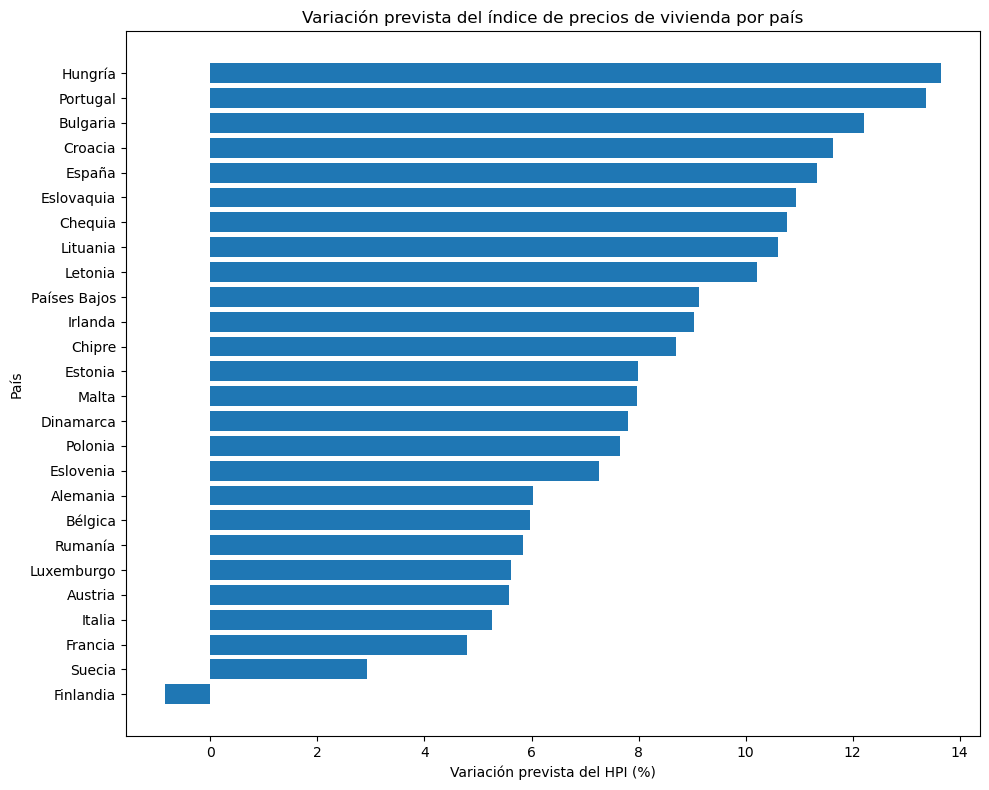

In [14]:
import matplotlib.pyplot as plt

top_growth = forecast_summary.sort_values(
    "expected_hpi_change_pct",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_growth["country"],
    top_growth["expected_hpi_change_pct"]
)

plt.xlabel("Variación prevista del HPI (%)")
plt.ylabel("País")
plt.title("Variación prevista del índice de precios de vivienda por país")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "forecast_expected_hpi_change_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

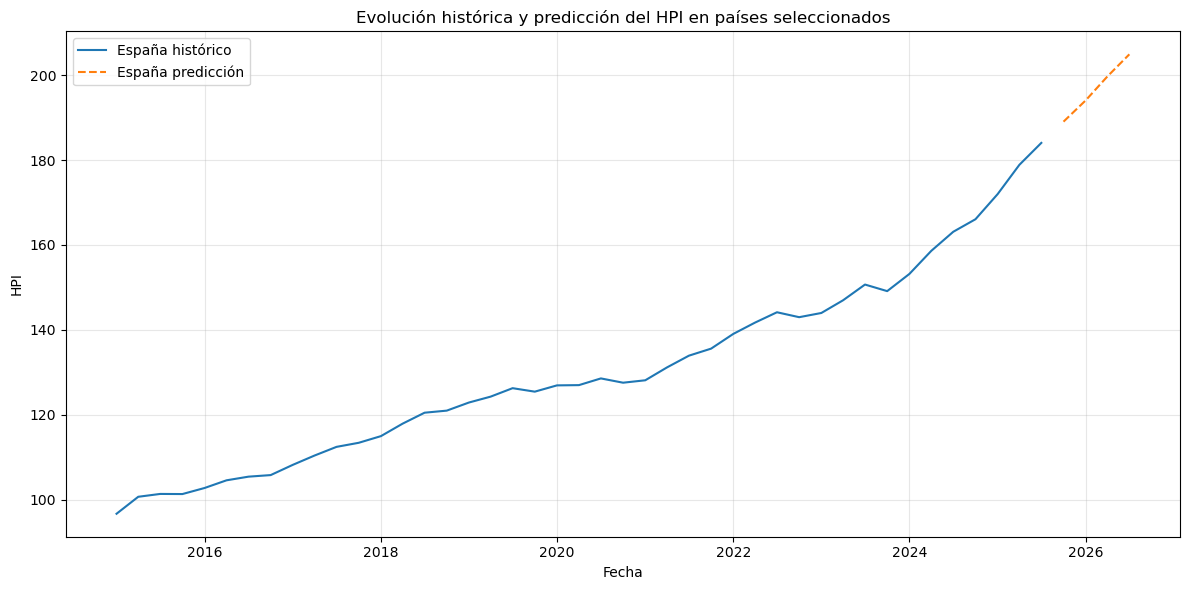

In [15]:
selected_countries = [
    "España"
]

plot_df = combined[
    combined["country"].isin(selected_countries)
].copy()

plt.figure(figsize=(12, 6))

for country in selected_countries:
    country_hist = plot_df[
        (plot_df["country"] == country) &
        (plot_df["type"] == "Histórico")
    ]

    country_forecast = plot_df[
        (plot_df["country"] == country) &
        (plot_df["type"] == "Predicción")
    ]

    plt.plot(
        country_hist["date"],
        country_hist["hpi"],
        label=f"{country} histórico"
    )

    plt.plot(
        country_forecast["date"],
        country_forecast["hpi"],
        linestyle="--",
        label=f"{country} predicción"
    )

plt.xlabel("Fecha")
plt.ylabel("HPI")
plt.title("Evolución histórica y predicción del HPI en países seleccionados")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "historical_forecast_selected_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()